In [61]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [62]:
N=int(1e4) #number of extractions

#Create the dictionary with the values extracted uniformly as intended
values = {} 
values['m1'] = np.random.uniform(10, 100, N)
values['chi1'] = np.random.uniform(0, 1, N)
values['m2'] = np.random.uniform(10, 100, N)
values['chi2'] = np.random.uniform(10, 100, N)
values['theta1'] = np.acos(np.random.uniform(-1, 1, N))
values['theta2'] = np.acos(np.random.uniform(-1, 1, N))

In [ ]:

#I create the dictionary containing all the values of the binary system
BBH_values = {}
BBH_values['M'] = values['m1']+values['m2'] #total mass
BBH_values['ChiEff'] = (values['chi1']*values['m1']*np.cos(values['theta1']) + values['chi2']*values['m2']*np.cos(values['theta2']))/(BBH_values['M']) #effective angular momenta
BBH_values['eta'] = values['m1']*values['m2']/(2*BBH_values['M']*BBH_values['M']) #symmetric mass ratio
BBH_values['chirpMass'] = (values['m1']*values['m2'])**(3/5)/(BBH_values['M'])**(1/5) #chirp mass
nu10=4.916e-5 
BBH_values['r0']=(BBH_values['M']/(math.pi*math.pi*nu10*nu10))**(1/3) 
BBH_values['tc'] = 50*nu10*BBH_values['r0']**4/(256*values['m1']*values['m2']*BBH_values['M']) #time spent in the sensitivity band of current gravitational-wave detectors

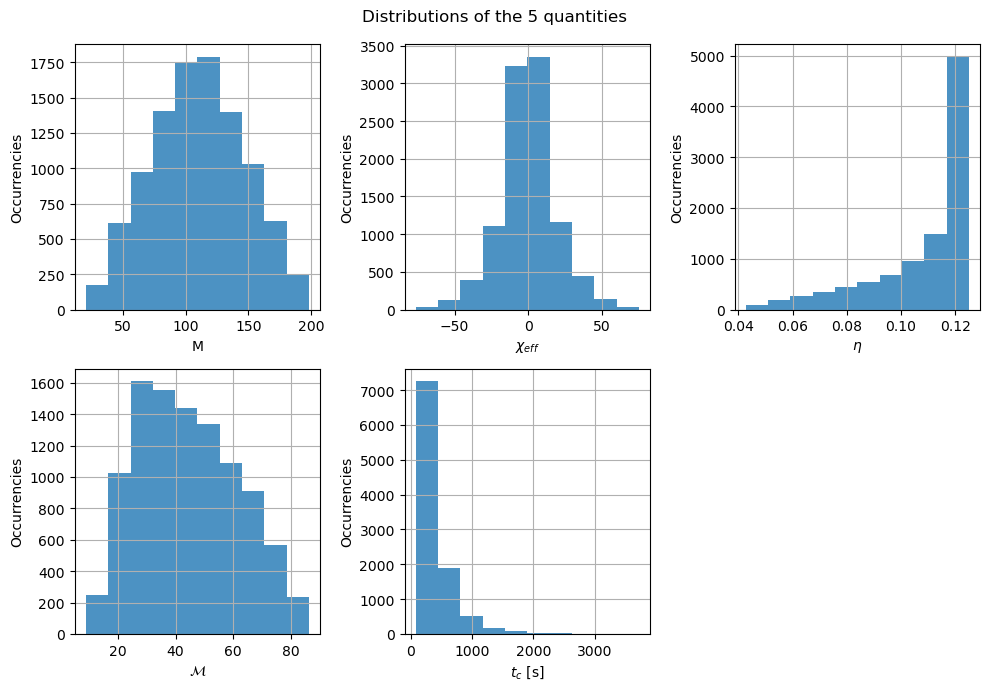

In [89]:
names = {1: 'M', 2: 'ChiEff', 3: 'eta', 4: 'chirpMass', 5: 'tc'}
x_labels = {1: 'M', 2: '$\\chi_{eff}$', 3: '$\\eta$', 4: '$\\mathcal{M}$', 5: '$t_c$ [s]'}

#create the figure
fig = plt.figure(figsize=(10,7))

#plot the 5 histograms
fig.suptitle('Distributions of the 5 quantities')
for i in range(1,6):
    ax = fig.add_subplot(2,3,i)
    ax.hist(BBH_values[names[i]], alpha=0.8)
    ax.set_ylabel('Occurrencies')
    ax.set_xlabel(x_labels[i])
    ax.grid()
fig.tight_layout();

Gamma: 9.38795 ± 0.78305; x0: -0.28806 ± 0.78305


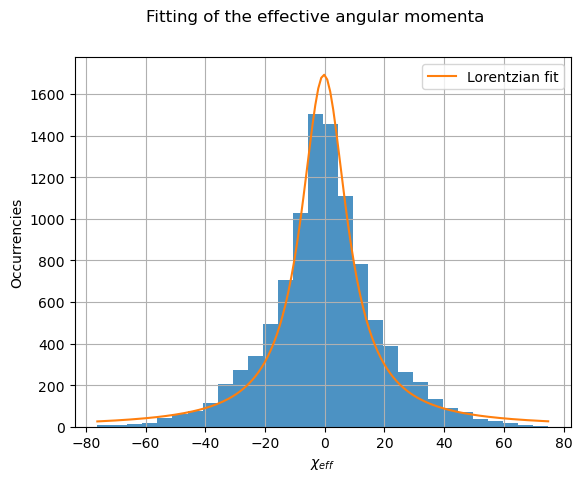

In [90]:
from scipy.optimize import curve_fit

#I do the plot of effective angular momenta
plt.suptitle('Fitting of the effective angular momenta')
h = plt.hist(BBH_values['ChiEff'], alpha=0.8, bins=30)
plt.ylabel('Occurrencies')
plt.xlabel('$\\chi_{eff}$')

#define the lorentzian
def function(x, gamma, x0, A):
    return A*gamma/(math.pi*((x-x0)**2+gamma**2))

#do the fitting
popt, pcov = curve_fit(function, [(h[1][i+1]+h[1][i])/2 for i in range(len(h[1])-1)], h[0], sigma=np.sqrt(h[0]), p0=[20, 0, 1500])

#Plot the fit and show the values
x = np.arange(min(h[1]), max(h[1]))
gamma = popt[0]
x0 = popt[1]
A = popt[2]

print(f"Gamma: %.5f \u00B1 %.5f; x0: %.5f \u00B1 %.5f" % (gamma, pcov[0][0]**0.5, x0, pcov[0][0]**0.5))
plt.plot(x, function(x, gamma, x0, A), label='Lorentzian fit')
plt.legend()
plt.grid();